**LIBRARIES**

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import heapq
import statistics
import collections

**DATA LOADING**

In [ ]:
def load_data(path, is_directed=False):
    graph_type = nx.DiGraph() if is_directed else nx.Graph()
    G = nx.read_edgelist(path, create_using=graph_type, nodetype=int)
    print(f"Nodes: {G.number_of_nodes():,}")
    print(f"Edges: {G.number_of_edges():,}")
    print(f"Density: {nx.density(G):.6f}")
    if is_directed:
        print(f"Weakly Connected Components: {nx.number_weakly_connected_components(G):,}")
    else:
        print(f"Connected Components: {nx.number_connected_components(G):,}")

    return G
G1 = load_data("/content/drive/MyDrive/Explo/Wiki-Vote.txt", is_directed=True)
G2 = load_data("/content/drive/MyDrive/Explo/facebook_combined.txt")

Nodes: 7,115
Edges: 103,689
Density: 0.002049
Weakly Connected Components: 24
Nodes: 4,039
Edges: 88,234
Density: 0.010820
Connected Components: 1


In [ ]:
class DiffusionModel:

    def __init__(self, G, seeds):
        self.G = G
        self.seeds = seeds

    def run(self):
        """
        Must return:
        {
            "history": dict or list,
            "final_spread": int,
            "diffusion_time": int
        }
        """
        raise NotImplementedError

**SEED SELECTION STRATEGIES**

In [ ]:
class Seed_Selection:
    def __init__(self, G, k):
        self.Graph = G
        self.seed_size = k
        self.degree_dict = dict(self.Graph.degree())
        self.betweenness_dict = nx.betweenness_centrality(self.Graph)
        self.closeness_dict = nx.closeness_centrality(self.Graph)

    def random_seeds(self):
        return set(random.sample(list(self.Graph.nodes()), self.seed_size))

    def degree_based(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.degree_dict,
            key=self.degree_dict.get
        )
        return set(top_k)

    def betweenness_seeds(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.betweenness_dict,
            key=self.betweenness_dict.get
        )
        return set(top_k)

    def closeness_seeds(self):
        top_k = heapq.nlargest(
            self.seed_size,
            self.closeness_dict,
            key=self.closeness_dict.get
        )
        return set(top_k)

    def greedy(self, diffusion_model, **kwargs):


        selected = set()
        current_spread = 0

        def simulate(seeds):
            model = diffusion_model(self.Graph, seeds, **kwargs)
            active_nodes, _ = model.run()
            return len(active_nodes)

        for _ in range(self.seed_size):

            best_node = None
            best_gain = -1

            for node in self.Graph.nodes():
                if node in selected:
                    continue

                spread = simulate(selected | {node})
                gain = spread - current_spread

                if gain > best_gain:
                    best_gain = gain
                    best_node = node

            selected.add(best_node)
            current_spread = simulate(selected)

            print(f"Selected {best_node} | Spread = {current_spread}")

        return selected


**MONTE CARLO SIMULATIONS**

In [ ]:
class SimulationRunner:

    def __init__(self, G, model_class, seeds, runs=20, random_seed=42, **params):

        self.G = G
        self.model_class = model_class
        self.seeds = seeds
        self.runs = runs
        self.random_seed = random_seed
        self.params = params

        self.results = []

    def run(self):

        for i in range(self.runs):

            random.seed(self.random_seed + i)

            model = self.model_class(self.G, self.seeds, **self.params)

            output = model.run()

            self.results.append(output)

        return self.aggregate()

    def aggregate(self):
       spreads = [r["final_spread"] for r in self.results]
       times = [r["diffusion_time"] for r in self.results]
       curves = [r["infected_curve"] for r in self.results]
       max_len = max(len(c) for c in curves)


       avg_curve = np.zeros(max_len)

       for c in curves:

           padded_curve = np.pad(c, (0, max_len - len(c)), mode='constant')
           avg_curve += padded_curve

       avg_curve /= self.runs

       return {
           "mean_spread": np.mean(spreads),
           "std_spread": np.std(spreads),
           "mean_diffusion_time": np.mean(times),
           "avg_prevalence_curve": avg_curve,
           "raw_results": self.results
       }

**PLOTTING FUNCTIONS**

In [ ]:
def compare_models(G, models, seeds, runs=20, **params):

    spreads = []

    for model in models:

        sim = SimulationRunner(G, model, seeds, runs=runs, **params)

        results = sim.run()

        spreads.append(results["mean_spread"])

    names = [m.__name__ for m in models]

    plt.figure()
    plt.bar(names, spreads)

    plt.ylabel("Mean Spread")
    plt.title("Model Comparison")

    plt.show()

In [ ]:
# 1. Diffusion Curve
def plot_diffusion_curve(results, t):
    run = results["raw_results"][0]
    history = run["history"]
    plt.figure()
    if isinstance(history, dict):
        if "I" in history:
            plt.plot(history["I"], label="Infected")

        if "S" in history:
            plt.plot(history["S"], label="Susceptible")

        if "R" in history:
            plt.plot(history["R"], label="Recovered")

        plt.legend()
    else:
        plt.plot(history)
    plt.xlabel("Time Step")
    plt.ylabel("Nodes")
    plt.title(t)
    plt.show()


# 2. Avg Prevalence Curve
def plot_avg_prevalence_curves(multi_results):
    plt.figure(figsize=(10, 6))

    for graph_name, results in multi_results.items():
        curve = results["avg_prevalence_curve"]
        plt.plot(range(len(curve)), curve, marker='o', linestyle='-', linewidth=2, label=graph_name)

    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel("Average Infected Nodes", fontsize=12)
    plt.title("Average Prevalence Over Time Across Datasets", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# 3. Average Final Spread
def plot_final_spreads(multi_results):
    plt.figure(figsize=(10, 6))

    names = list(multi_results.keys())
    means = [results["mean_spread"] for results in multi_results.values()]

    plt.bar(names, means, color='skyblue', edgecolor='black')
    plt.ylabel("Active Nodes", fontsize=12)
    plt.title("Average Final Spread Across Datasets", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 4. Spread Distribution
def plot_spread_distributions(multi_results):
    plt.figure(figsize=(10, 6))

    for graph_name, results in multi_results.items():
        spreads = [r["final_spread"] for r in results["raw_results"]]
        plt.hist(spreads, bins=10, alpha=0.6, label=graph_name, edgecolor='black')

    plt.xlabel("Final Spread", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Spread Distribution Across Runs", fontsize=14)
    plt.legend()
    plt.show()

# 5. Diffusion Time
def plot_diffusion_times(multi_results):
    plt.figure(figsize=(10, 6))

    names = list(multi_results.keys())
    times = [results["mean_diffusion_time"] for results in multi_results.values()]

    plt.bar(names, times, color='lightgreen', edgecolor='black')
    plt.ylabel("Time Steps", fontsize=12)
    plt.title("Average Diffusion Time Across Datasets", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 6. Variance Plot
def plot_variances(multi_results):
    plt.figure(figsize=(10, 6))

    data_to_plot = []
    labels = []

    for graph_name, results in multi_results.items():
        spreads = [r["final_spread"] for r in results["raw_results"]]
        data_to_plot.append(spreads)
        labels.append(graph_name)
    plt.boxplot(data_to_plot, tick_labels=labels, patch_artist=True)
    plt.ylabel("Final Spread", fontsize=12)
    plt.title("Spread Variability Across Datasets", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [ ]:
def compare_seed_strategies_across_graphs(graphs_dict, model_class, k, runs=20, **model_params):
    """
    Compares seed selection strategies across multiple graphs and plots a grouped bar chart.
    """
    graph_names = list(graphs_dict.keys())
    means_random = []
    means_hd = []
    errors_random = []
    errors_hd = []

    all_results = {}

    for graph_name, G in graphs_dict.items():
        print(f"Testing strategies on {graph_name}...")
        selector = Seed_Selection(G, k)

        # 1. Random seeds
        seeds_random = selector.random_seeds()
        sim_random = SimulationRunner(
            G, model_class, seeds_random, runs=runs, **model_params
        )
        results_random = sim_random.run()

        means_random.append(results_random["mean_spread"])
        errors_random.append(results_random["std_spread"])

        # 2. High degree seeds
        seeds_hd = selector.degree_based()
        sim_hd = SimulationRunner(
            G, model_class, seeds_hd, runs=runs, **model_params
        )
        results_hd = sim_hd.run()

        means_hd.append(results_hd["mean_spread"])
        errors_hd.append(results_hd["std_spread"])

        # Store all data
        all_results[graph_name] = {
            "random": results_random,
            "high_degree": results_hd
        }

    # 3. Visualization (Grouped Bar Chart)
    x = np.arange(len(graph_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(x - width/2, means_random, width, yerr=errors_random, capsize=5,
           label='Random Seeds', color='skyblue', edgecolor='black')
    ax.bar(x + width/2, means_hd, width, yerr=errors_hd, capsize=5,
           label='High Degree Seeds', color='salmon', edgecolor='black')

    ax.set_ylabel("Mean Final Spread", fontsize=12)
    ax.set_title(f"{model_class.__name__}: Seed Strategy Comparison (k={k}) Across Datasets", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(graph_names)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.tight_layout()
    plt.show()

    return all_results

In [ ]:
def analyze_seed_sizes_across_graphs(graphs_dict, model_class, seed_strategy="Random",
                                     seed_sizes=[5, 10, 20, 50, 100], runs=20, **params):

    all_results = {}

    plt.figure(figsize=(10, 6))

    for graph_name, G in graphs_dict.items():
        print(f"\n--- Running seed size analysis on {graph_name} ---")
        mean_spreads = []

        for k in seed_sizes:
            selector = Seed_Selection(G, k)

            if seed_strategy == "Random":
                seeds = selector.random_seeds()
            else:
                seeds = selector.degree_based()

            sim = SimulationRunner(G, model_class, seeds, runs=runs, **params)
            results = sim.run()

            mean_spread_val = results["mean_spread"]
            mean_spreads.append(mean_spread_val)

            print(f"  k={k} | Mean Spread: {mean_spread_val:.2f}")


        all_results[graph_name] = dict(zip(seed_sizes, mean_spreads))


        plt.plot(seed_sizes, mean_spreads, marker='o', linestyle='-', linewidth=2, label=graph_name)


    plt.xlabel("Seed Size (k)", fontsize=12)
    plt.ylabel("Mean Spread", fontsize=12)
    plt.title(f"{model_class.__name__} Spread vs Seed Size ({seed_strategy} Strategy)", fontsize=14)

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return all_results

**EPIDEMIC MODLES**

*SIR Model*

In [ ]:
class SIR:
    def __init__(self, G, seeds, beta=0.3, gamma=0.1):
        self.G = G
        self.beta = beta
        self.gamma = gamma
        self.infected_nodes = set(seeds)
        self.susceptible_nodes = set(G.nodes()) - self.infected_nodes
        self.recovered_nodes = set()
        self.history = {
            "S": [len(self.susceptible_nodes)],
            "I": [len(self.infected_nodes)],
            "R": [0]
        }

    def step(self):
        new_infections = set()
        new_recoveries = set()

        # 1. Infection Phase: Only check neighbors of current 'I' nodes
        for u in self.infected_nodes:
            for v in self.G.neighbors(u):
                if v in self.susceptible_nodes:
                    if random.random() <= self.beta:
                        new_infections.add(v)

        # 2. Recovery Phase: Current 'I' nodes might move to 'R'
        for u in self.infected_nodes:
            if random.random() <= self.gamma:
                new_recoveries.add(u)

        # 3. State Updates
        self.susceptible_nodes -= new_infections
        self.infected_nodes |= new_infections
        self.infected_nodes -= new_recoveries
        self.recovered_nodes |= new_recoveries

        # 4. Record History
        self.history["S"].append(len(self.susceptible_nodes))
        self.history["I"].append(len(self.infected_nodes))
        self.history["R"].append(len(self.recovered_nodes))

    def run(self, max_steps=100):
        for _ in range(max_steps):
            if self.history["I"][-1] == 0:
                break
            self.step()

        return {
            "history": self.history,
            "final_spread": self.history["R"][-1],
            "diffusion_time": len(self.history["I"]),
            "infected_curve": self.history["I"]
        }

In [ ]:
#Seeds
seed_class1 = Seed_Selection(G1, 20)
seeds1 = seed_class1.random_seeds()
seed_class2 = Seed_Selection(G2, 20)
seeds2 = seed_class2.random_seeds()


#Params
params = {"beta": 0.4, "gamma": 0.2}

runner1a = SimulationRunner(G1, SIR, seeds1, runs=10, **params)
results1a = runner1a.run()
runner1b = SimulationRunner(G2, SIR, seeds2, runs=10, **params)
results1b = runner1b.run()

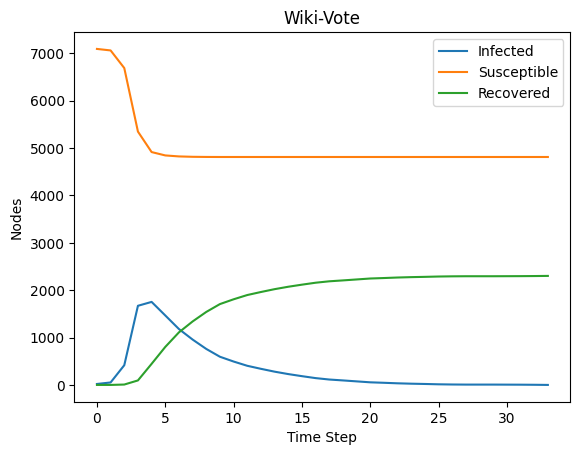

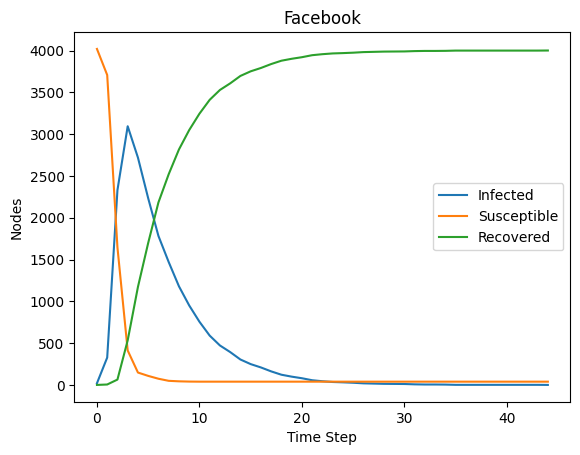

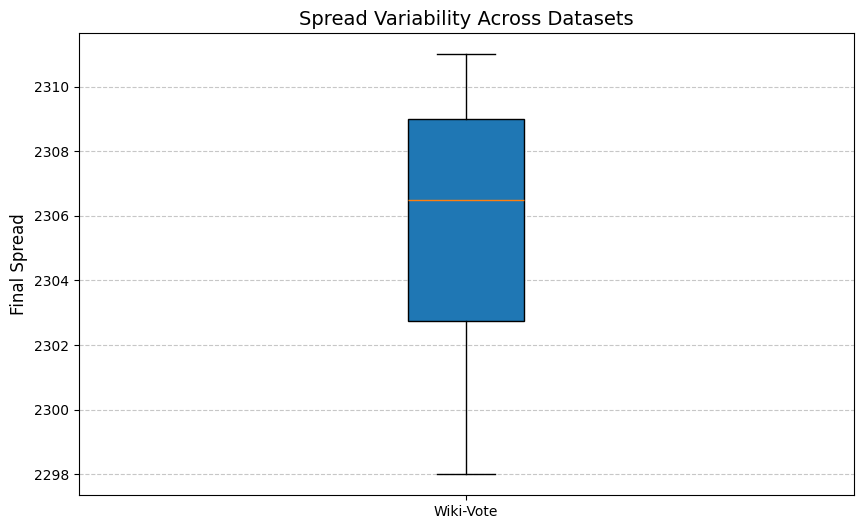

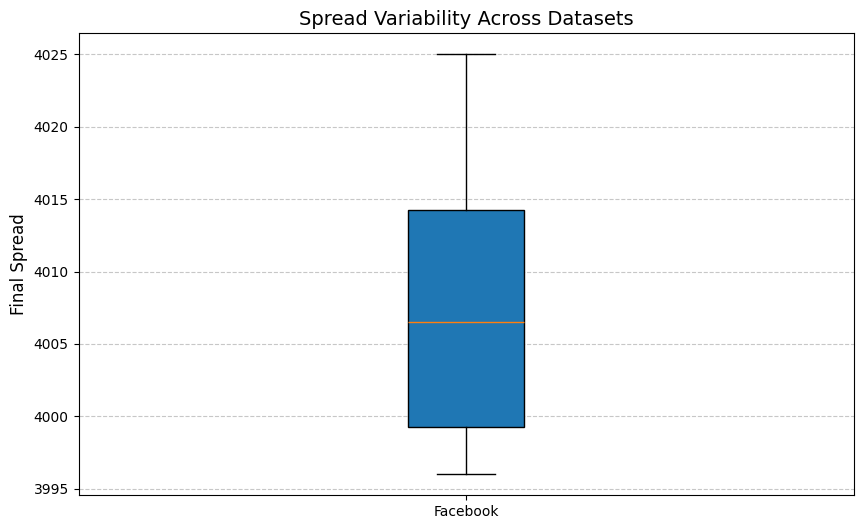

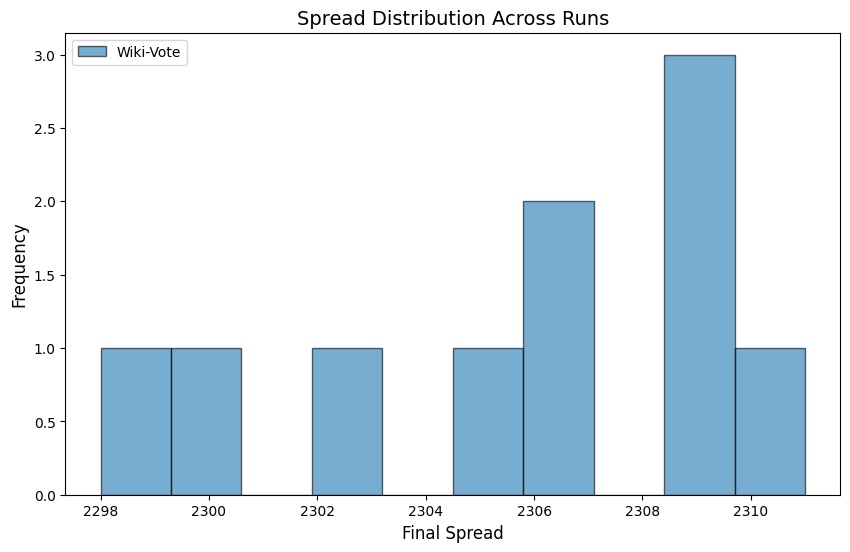

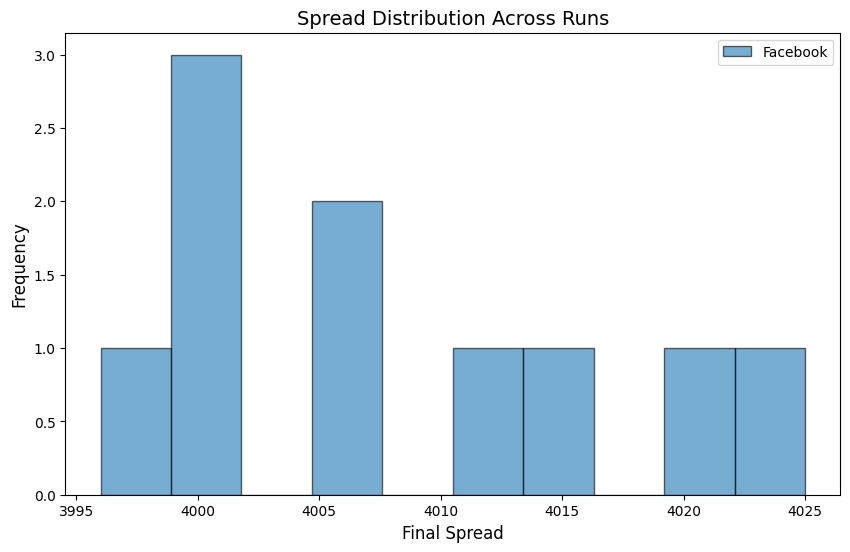

In [ ]:
plot_diffusion_curve(results1a, "Wiki-Vote")
plot_diffusion_curve(results1b, "Facebook")
plot_variances({"Wiki-Vote" : results1a})
plot_variances({"Facebook" : results1b})
plot_spread_distributions({"Wiki-Vote" : results1a})
plot_spread_distributions({"Facebook" : results1b})

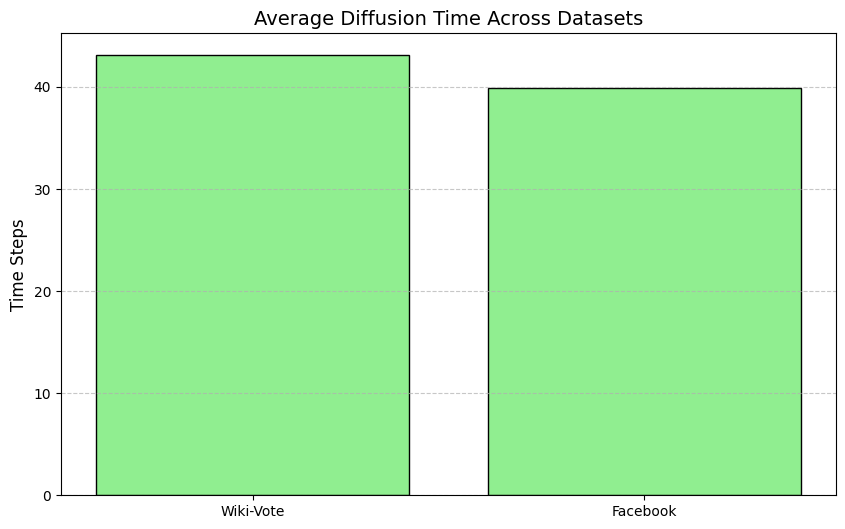

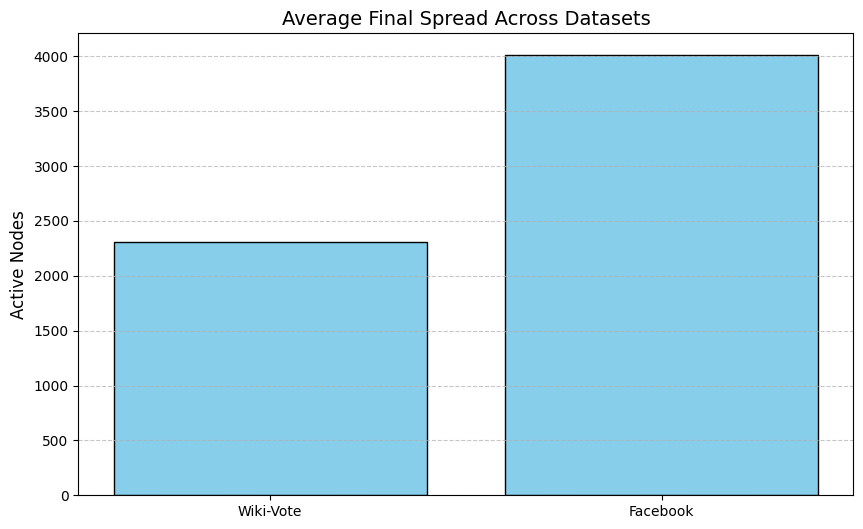

In [ ]:
all_results = {
    "Wiki-Vote": results1a,
    "Facebook": results1b,
}
plot_diffusion_times(all_results)
plot_final_spreads(all_results)

Testing strategies on Wiki-Vote...
Testing strategies on Facebook...


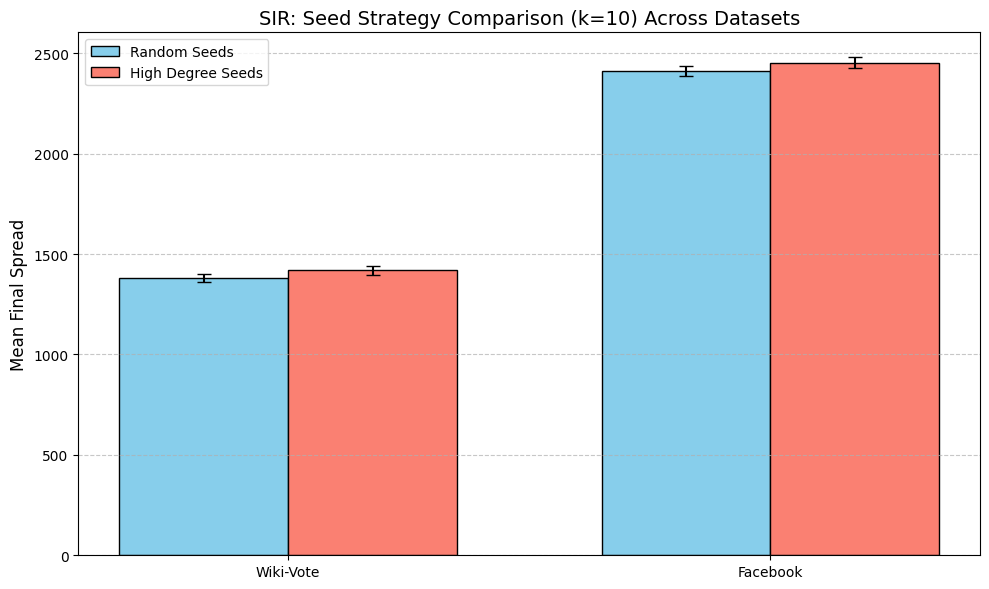


--- Running seed size analysis on Wiki-Vote ---
  k=5 | Mean Spread: 1410.55
  k=10 | Mean Spread: 1419.75
  k=20 | Mean Spread: 1420.15
  k=50 | Mean Spread: 1430.90
  k=100 | Mean Spread: 1441.80

--- Running seed size analysis on Facebook ---
  k=5 | Mean Spread: 2448.80
  k=10 | Mean Spread: 2453.85
  k=20 | Mean Spread: 2457.50
  k=50 | Mean Spread: 2459.50
  k=100 | Mean Spread: 2457.05


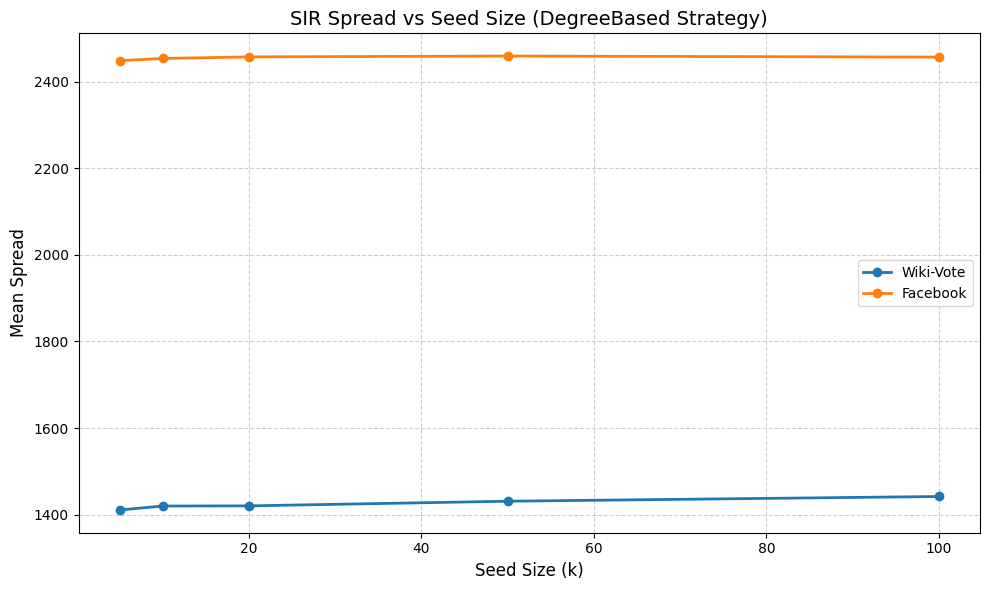

{'Wiki-Vote': {5: np.float64(1410.55),
  10: np.float64(1419.75),
  20: np.float64(1420.15),
  50: np.float64(1430.9),
  100: np.float64(1441.8)},
 'Facebook': {5: np.float64(2448.8),
  10: np.float64(2453.85),
  20: np.float64(2457.5),
  50: np.float64(2459.5),
  100: np.float64(2457.05)}}

In [ ]:
Graph_dict = {
    "Wiki-Vote": G1,
    "Facebook": G2
    }
compare_seed_strategies_across_graphs(Graph_dict, SIR, k=10, runs=20, beta=0.05, gamma=0.01)

analyze_seed_sizes_across_graphs(Graph_dict, SIR, seed_strategy="DegreeBased", runs=20, beta=0.05, gamma=0.01)

*SIS Model*

In [ ]:
class SIS:
    def __init__(self, G, seeds, beta=0.2, gamma=0.1):
        self.G = G
        self.beta = beta
        self.gamma = gamma

        self.infected_nodes = set(seeds)
        self.susceptible_nodes = set(G.nodes()) - self.infected_nodes

        self.history = {
            "S": [len(self.susceptible_nodes)],
            "I": [len(self.infected_nodes)]
        }

    def step(self):
        new_infections = set()
        new_recoveries = set()

        # 1. Infection Phase (S -> I)
        for u in self.infected_nodes:
            for v in self.G.neighbors(u):
                if v in self.susceptible_nodes:
                    if random.random() <= self.beta:
                        new_infections.add(v)

        # 2. Recovery Phase (I -> S)
        for u in self.infected_nodes:
            if random.random() <= self.gamma:
                new_recoveries.add(u)

        # 3. State Updates (Atomic transitions)
        self.susceptible_nodes -= new_infections
        self.susceptible_nodes |= new_recoveries

        self.infected_nodes |= new_infections
        self.infected_nodes -= new_recoveries

        # 4. Record History
        self.history["S"].append(len(self.susceptible_nodes))
        self.history["I"].append(len(self.infected_nodes))

    def run(self, max_steps=100):
        for _ in range(max_steps):
            if len(self.infected_nodes) == 0:
                break
            self.step()

        return {
            "history": self.history,
            "final_spread": self.history["I"][-1],
            "diffusion_time": len(self.history["I"]),
            "infected_curve": self.history["I"]
        }

In [ ]:
#Seeds
seed_class1 = Seed_Selection(G1, 20)
seeds1 = seed_class1.random_seeds()
seed_class2 = Seed_Selection(G2, 20)
seeds2 = seed_class2.random_seeds()


#Params
params = {"beta": 0.08, "gamma": 0.2}

runner2a = SimulationRunner(G1, SIS, seeds1, runs=10, **params)
results2a = runner2a.run()
runner2b = SimulationRunner(G2, SIS, seeds2, runs=10, **params)
results2b = runner2b.run()

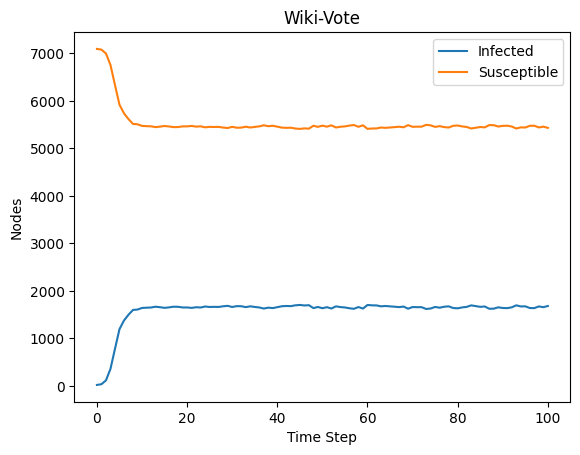

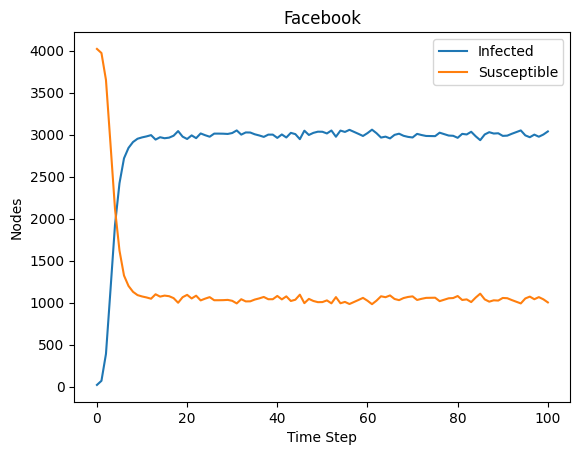

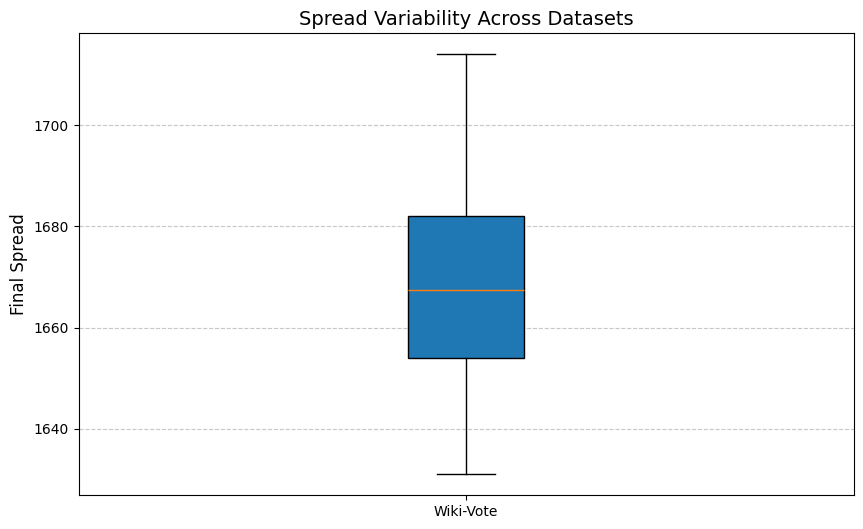

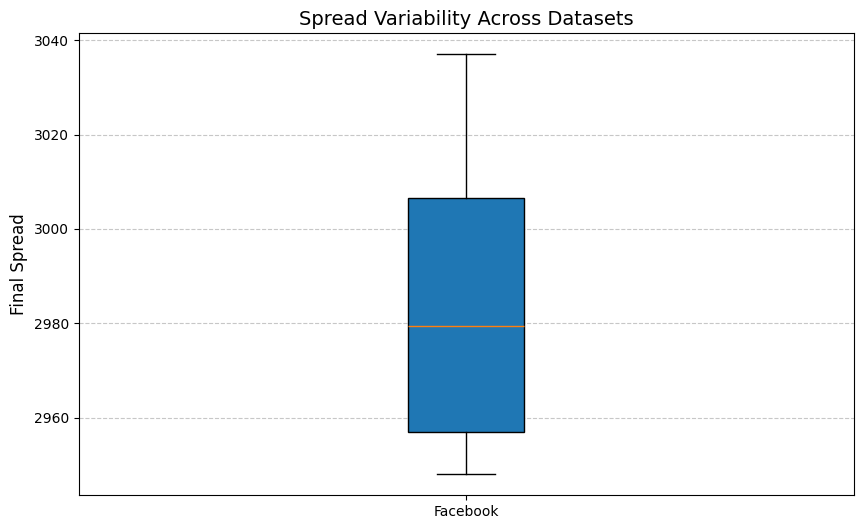

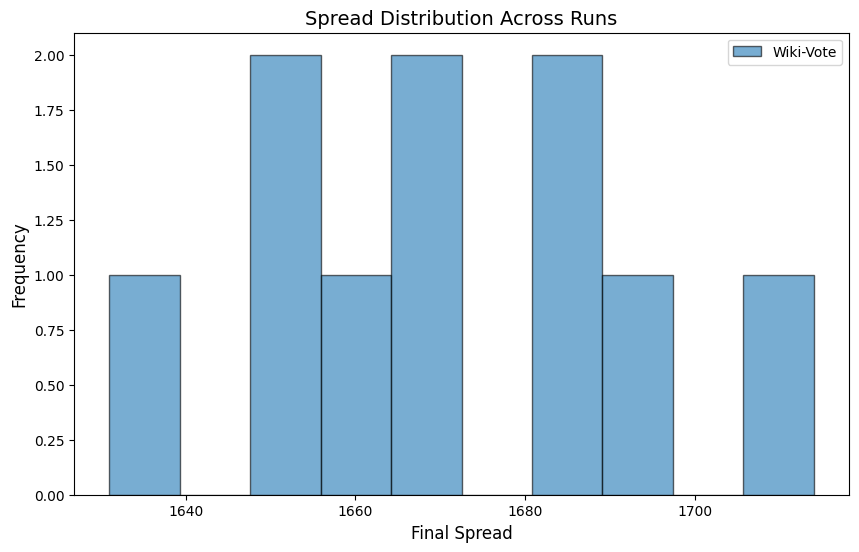

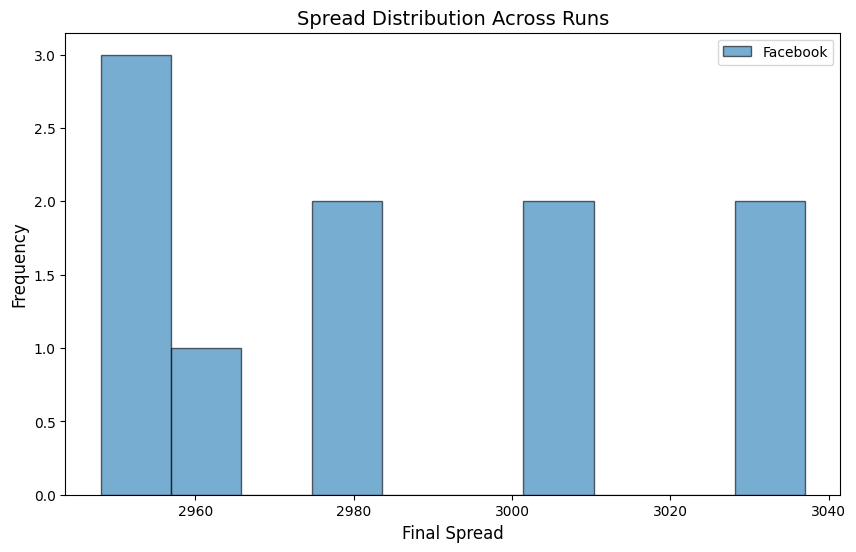

In [ ]:
plot_diffusion_curve(results2a, "Wiki-Vote")
plot_diffusion_curve(results2b, "Facebook")
plot_variances({"Wiki-Vote" : results2a})
plot_variances({"Facebook" : results2b})
plot_spread_distributions({"Wiki-Vote" : results2a})
plot_spread_distributions({"Facebook" : results2b})

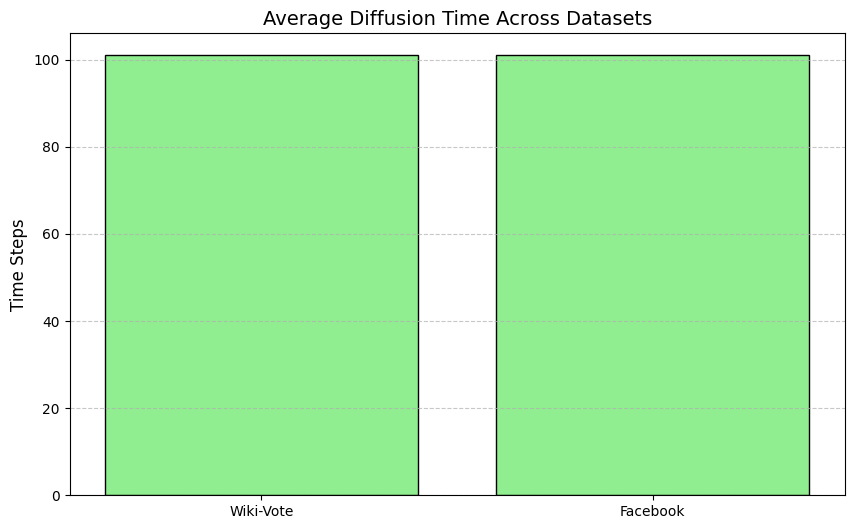

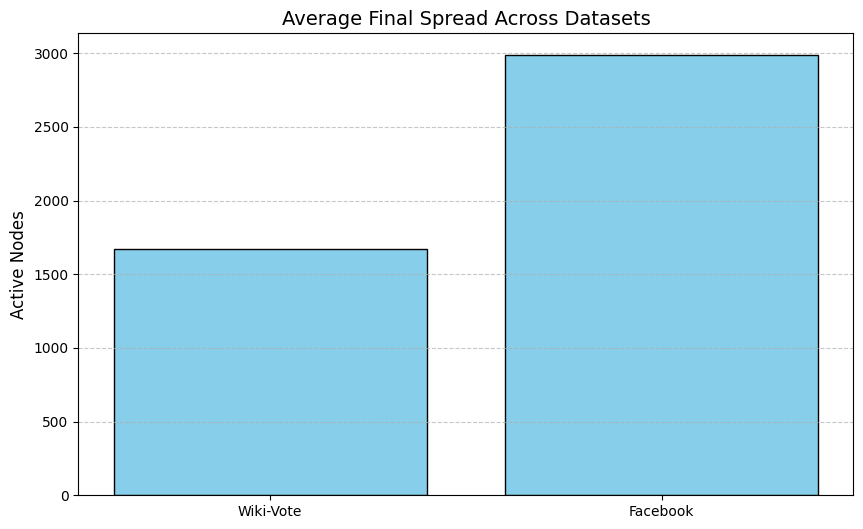

In [ ]:
all_results = {
    "Wiki-Vote": results2a,
    "Facebook": results2b,
}
plot_diffusion_times(all_results)
plot_final_spreads(all_results)

Testing strategies on Wiki-Vote...
Testing strategies on Facebook...


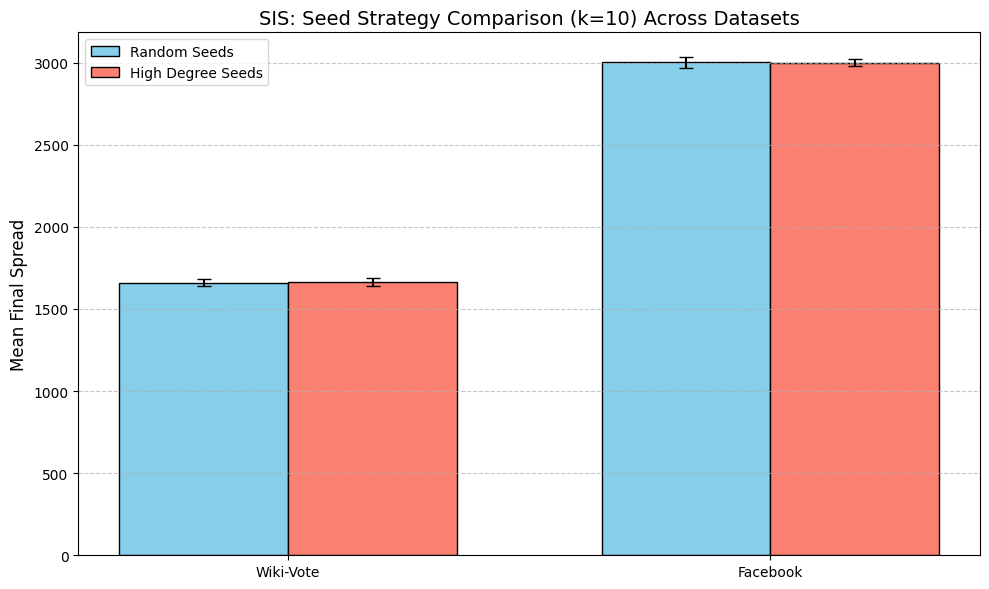


--- Running seed size analysis on Wiki-Vote ---
  k=5 | Mean Spread: 1665.55
  k=10 | Mean Spread: 1663.00
  k=20 | Mean Spread: 1652.70
  k=50 | Mean Spread: 1658.45
  k=100 | Mean Spread: 1667.75

--- Running seed size analysis on Facebook ---
  k=5 | Mean Spread: 3002.50
  k=10 | Mean Spread: 3000.15
  k=20 | Mean Spread: 2996.55
  k=50 | Mean Spread: 2998.40
  k=100 | Mean Spread: 3003.70


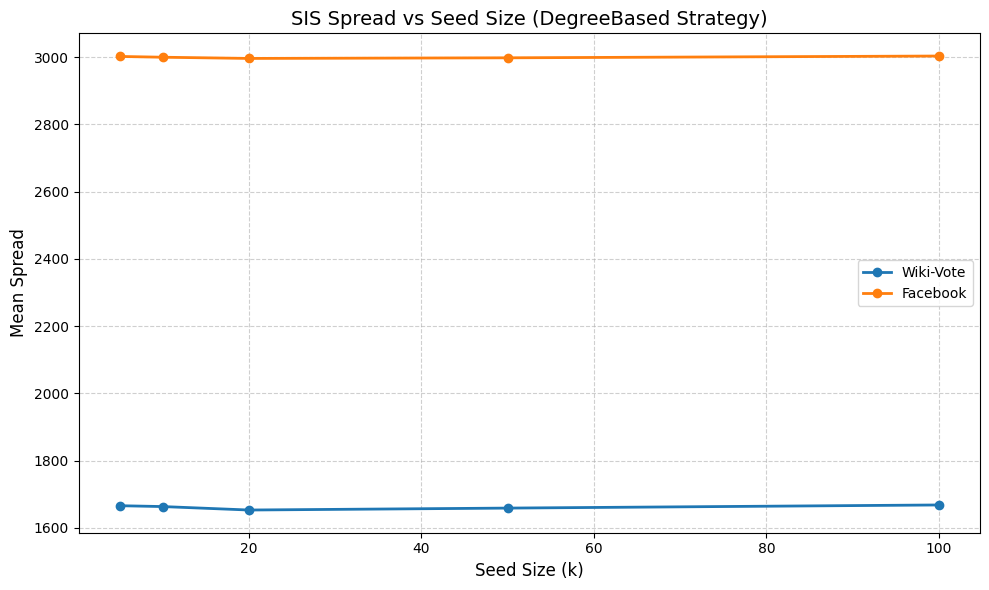

{'Wiki-Vote': {5: np.float64(1665.55),
  10: np.float64(1663.0),
  20: np.float64(1652.7),
  50: np.float64(1658.45),
  100: np.float64(1667.75)},
 'Facebook': {5: np.float64(3002.5),
  10: np.float64(3000.15),
  20: np.float64(2996.55),
  50: np.float64(2998.4),
  100: np.float64(3003.7)}}

In [ ]:
Graph_dict = {
    "Wiki-Vote": G1,
    "Facebook": G2
    }
compare_seed_strategies_across_graphs(Graph_dict, SIS, k=10, runs=20, beta=0.08, gamma=0.2)

analyze_seed_sizes_across_graphs(Graph_dict, SIS, seed_strategy="DegreeBased", runs=20, beta=0.08, gamma=0.2)

*SIRS Model*

In [ ]:
class SIRS:
    def __init__(self, G, seeds, beta=0.2, gamma=0.1, f=0.05):

        self.G = G
        self.beta = beta
        self.gamma = gamma
        self.f = f

        self.infected_nodes = set(seeds)
        self.recovered_nodes = set()
        self.susceptible_nodes = set(G.nodes()) - self.infected_nodes

        self.history = {
            "S": [len(self.susceptible_nodes)],
            "I": [len(self.infected_nodes)],
            "R": [0]
        }

    def step(self):
        new_infections = set()
        new_recoveries = set()
        new_susceptibles = set()

        # 1. Infection Phase (S -> I)
        for u in self.infected_nodes:
            for v in self.G.neighbors(u):
                if v in self.susceptible_nodes:
                    if random.random() <= self.beta:
                        new_infections.add(v)

        # 2. Recovery Phase (I -> R)
        for u in self.infected_nodes:
            if random.random() <= self.gamma:
                new_recoveries.add(u)

        # 3. Immunity Loss Phase (R -> S)
        for u in self.recovered_nodes:
            if random.random() <= self.f:
                new_susceptibles.add(u)

        # 4. State Updates (Atomic transitions)
        self.susceptible_nodes -= new_infections
        self.susceptible_nodes |= new_susceptibles

        self.infected_nodes |= new_infections
        self.infected_nodes -= new_recoveries

        self.recovered_nodes |= new_recoveries
        self.recovered_nodes -= new_susceptibles

        # 5. Record History
        self.history["S"].append(len(self.susceptible_nodes))
        self.history["I"].append(len(self.infected_nodes))
        self.history["R"].append(len(self.recovered_nodes))

    def run(self, max_steps=100):
        for _ in range(max_steps):
            if len(self.infected_nodes) == 0:
                if len(self.recovered_nodes) == 0:
                    break
            self.step()

        return {
            "history": self.history,
            "final_spread": self.history["I"][-1] + self.history["R"][-1],
            "diffusion_time": len(self.history["I"]),
            "infected_curve": self.history["I"]
        }

In [ ]:
#Seeds
seed_class1 = Seed_Selection(G1, 20)
seeds1 = seed_class1.random_seeds()
seed_class2 = Seed_Selection(G2, 20)
seeds2 = seed_class2.random_seeds()


#Params
params = {"beta": 0.03, "gamma": 0.1, "f": 0.02}

runner3a = SimulationRunner(G1, SIRS, seeds1, runs=10, **params)
results3a = runner3a.run()
runner3b = SimulationRunner(G2, SIRS, seeds2, runs=10, **params)
results3b = runner3b.run()

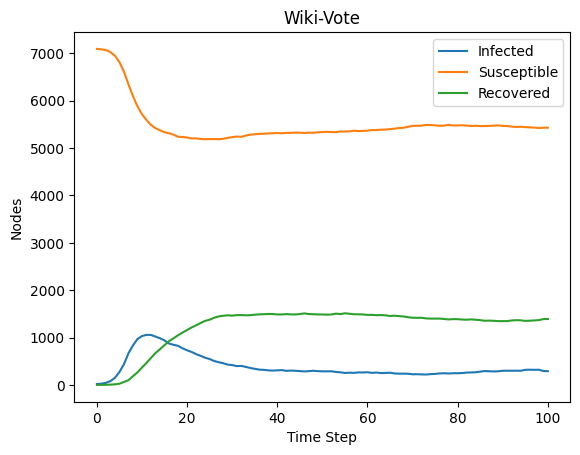

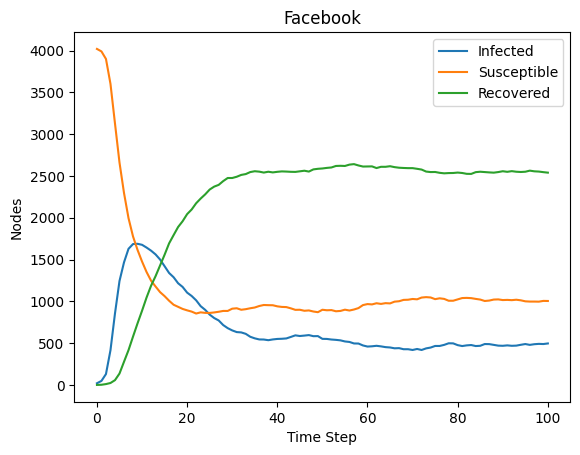

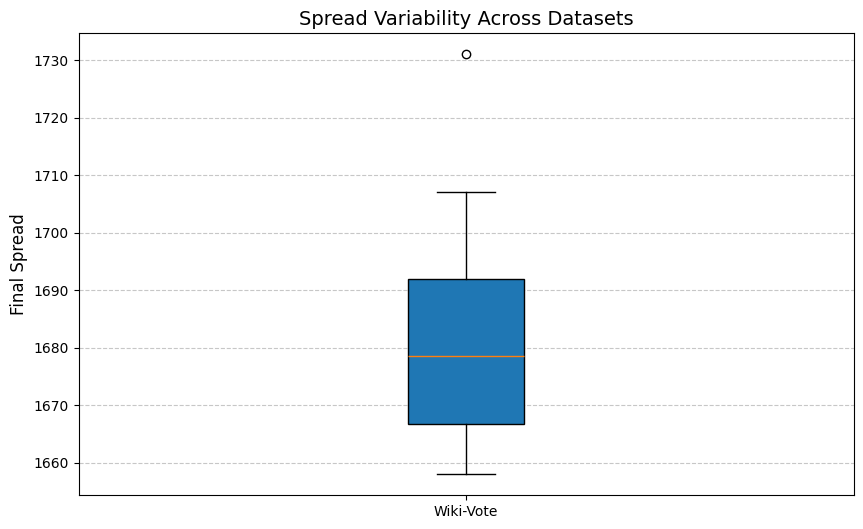

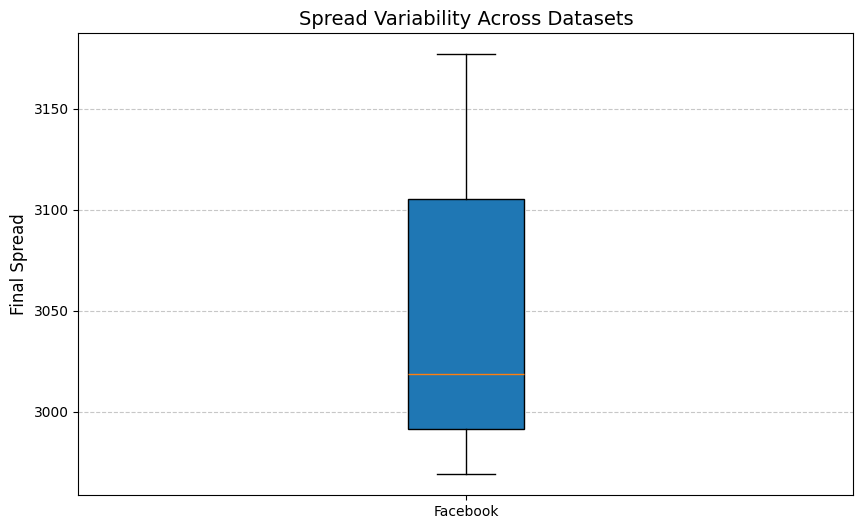

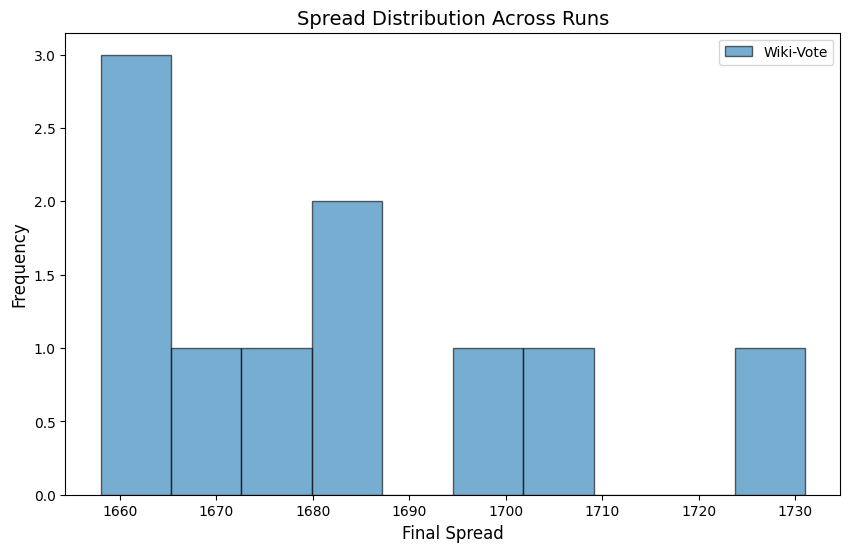

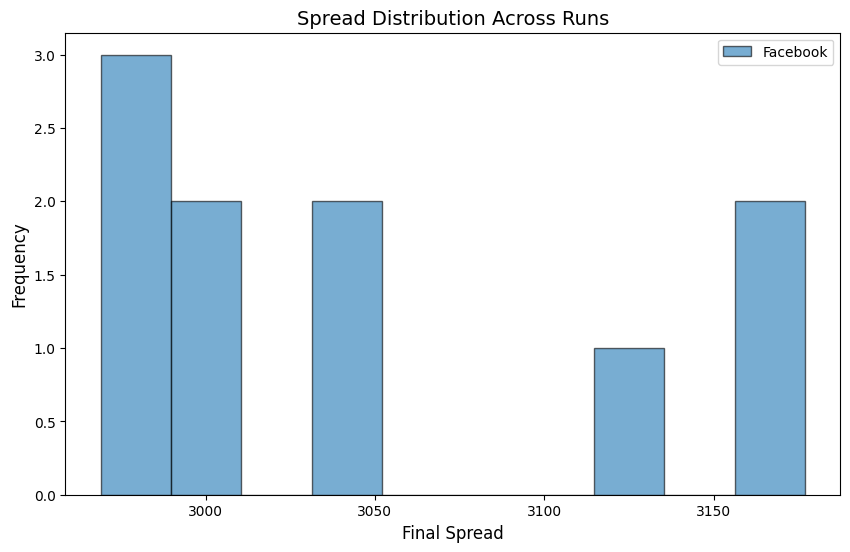

In [ ]:
plot_diffusion_curve(results3a, "Wiki-Vote")
plot_diffusion_curve(results3b, "Facebook")
plot_variances({"Wiki-Vote" : results3a})
plot_variances({"Facebook" : results3b})
plot_spread_distributions({"Wiki-Vote" : results3a})
plot_spread_distributions({"Facebook" : results3b})

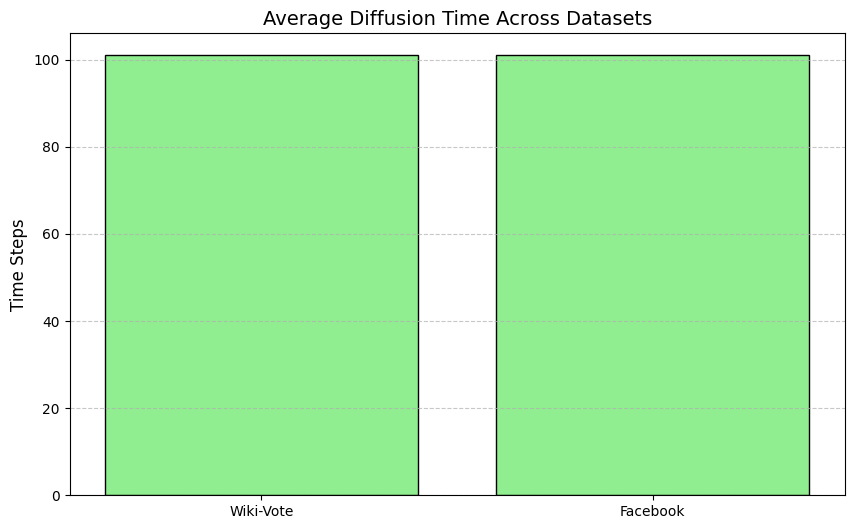

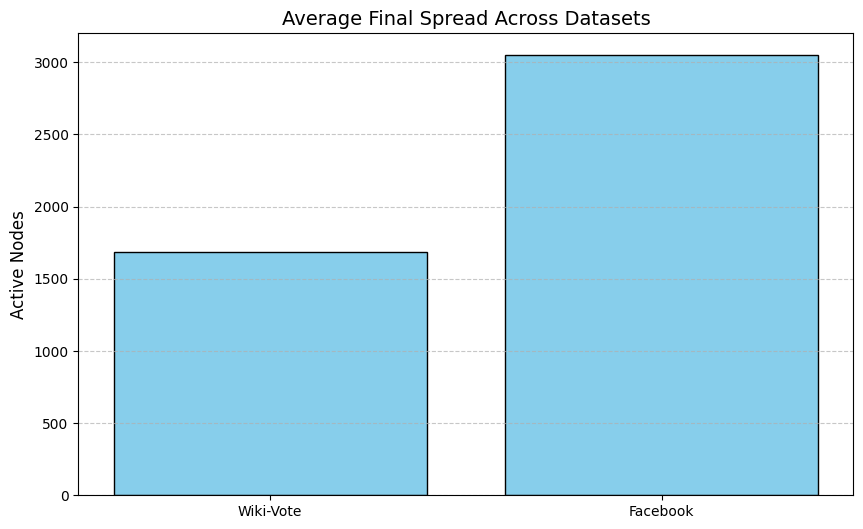

In [ ]:
all_results = {
    "Wiki-Vote": results3a,
    "Facebook": results3b,
}
plot_diffusion_times(all_results)
plot_final_spreads(all_results)

Testing strategies on Wiki-Vote...
Testing strategies on Facebook...


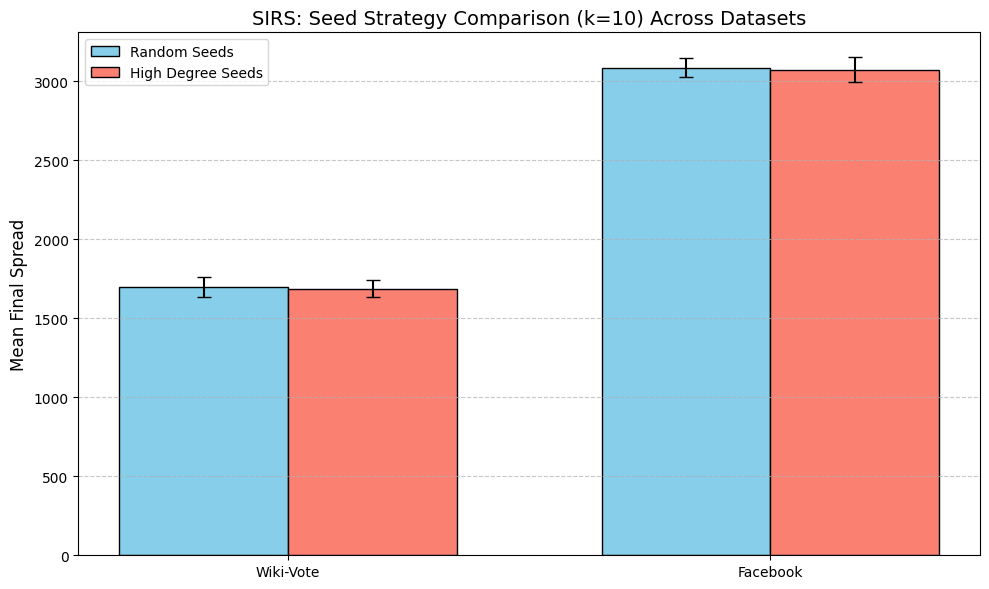


--- Running seed size analysis on Wiki-Vote ---
  k=5 | Mean Spread: 1698.50
  k=10 | Mean Spread: 1688.30
  k=20 | Mean Spread: 1690.00
  k=50 | Mean Spread: 1699.90
  k=100 | Mean Spread: 1716.25

--- Running seed size analysis on Facebook ---
  k=5 | Mean Spread: 3086.20
  k=10 | Mean Spread: 3073.30
  k=20 | Mean Spread: 3117.05
  k=50 | Mean Spread: 3061.90
  k=100 | Mean Spread: 3080.45


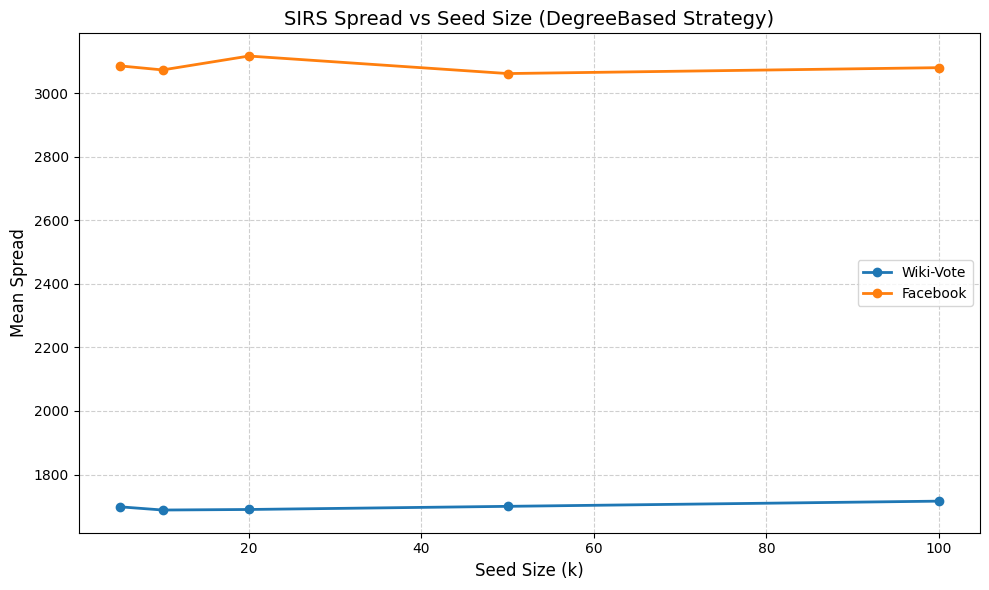

{'Wiki-Vote': {5: np.float64(1698.5),
  10: np.float64(1688.3),
  20: np.float64(1690.0),
  50: np.float64(1699.9),
  100: np.float64(1716.25)},
 'Facebook': {5: np.float64(3086.2),
  10: np.float64(3073.3),
  20: np.float64(3117.05),
  50: np.float64(3061.9),
  100: np.float64(3080.45)}}

In [ ]:
Graph_dict = {
    "Wiki-Vote": G1,
    "Facebook": G2
    }
compare_seed_strategies_across_graphs(Graph_dict, SIRS, k=10, runs=20, beta=0.03, gamma=0.1, f = 0.02)

analyze_seed_sizes_across_graphs(Graph_dict, SIRS, seed_strategy="DegreeBased", runs=20, beta=0.03, gamma=0.1, f = 0.02)

**COMPARISON OF THE THREE MODELS**

In [ ]:
def compare_models_across_graphs(graphs_dict, models_with_params, k=10, seed_strategy="DegreeBased", runs=20):
    model_names = [m[0].__name__ for m in models_with_params]

    x = np.arange(len(model_names))
    num_graphs = len(graphs_dict)
    width = 0.8 / num_graphs

    plt.figure(figsize=(12, 6))

    for i, (graph_name, G) in enumerate(graphs_dict.items()):
        means = []
        print(f"Running models on {graph_name}...")

        # 1. GENERATE SEEDS SPECIFIC TO THIS GRAPH
        selector = Seed_Selection(G, k)
        if seed_strategy == "Random":
            current_seeds = selector.random_seeds()
        else:
            current_seeds = selector.degree_based()

        for model_class, params in models_with_params:
            # 2. PASS THE GRAPH-SPECIFIC SEEDS INTO THE RUNNER
            sim = SimulationRunner(G, model_class, current_seeds, runs=runs, **params)
            results = sim.run()
            means.append(results["mean_spread"])

        offset = (i - num_graphs / 2 + 0.5) * width
        plt.bar(x + offset, means, width, label=graph_name, edgecolor='black')

    plt.ylabel("Mean Spread", fontsize=12)
    plt.title("Model Comparison Across Datasets", fontsize=14)
    plt.xticks(x, model_names, rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Running models on Wiki-Vote...
Running models on Facebook...


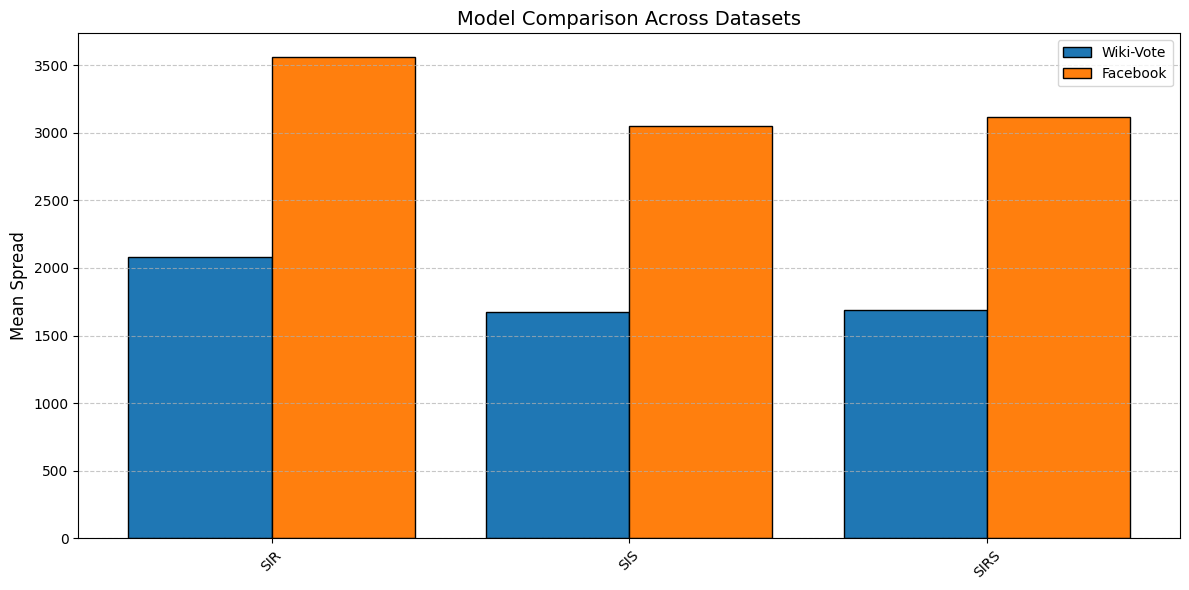

In [ ]:
Graph_dict = {
    "Wiki-Vote": G1,
    "Facebook": G2
    }
my_models = [
    (SIR, {"beta": 0.03, "gamma": 0.10}),
    (SIS, {"beta": 0.03, "gamma": 0.10}),
    (SIRS, {"beta": 0.03, "gamma": 0.10, "f": 0.02})
]
compare_models_across_graphs(
    Graph_dict,
    my_models,
    k=20,
    seed_strategy="DegreeBased",
    runs=20
)